<a href="https://colab.research.google.com/github/exort-design/Sakib-Khan/blob/main/Sta_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, binom, expon, pearsonr, ttest_ind
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("Number of observations (rows):", df.shape[0])
print("Number of variables (columns):", df.shape[1])
print("\nVariable names:")
print(list(df.columns))
print("\nData types:")
print(df.dtypes)
df.info()

Number of observations (rows): 768
Number of variables (columns): 9

Variable names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   

In [6]:
cols = ['Glucose', 'BMI', 'Age', 'Insulin']

desc_table = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Mode': df[cols].mode().iloc[0],
    'Variance': df[cols].var(),
    'Std Dev': df[cols].std()
})
desc_table = desc_table.round(2)
desc_table

,Mean,Median,Mode,Variance,Std Dev
Glucose,120.89,117.0,99.0,1022.25,31.97
BMI,31.99,32.0,32.0,62.16,7.88
Age,33.24,29.0,22.0,138.30,11.76
Insulin,79.80,30.5,0.0,13281.18,115.24


In [7]:
cols_check = ['Glucose', 'BMI', 'BloodPressure', 'Insulin']
print("Zero-value counts (likely missing data):\n")
for c in cols_check:
    zero_count = (df[c] == 0).sum()
    pct = zero_count / len(df) * 100
    print(f"{c:15s}: {zero_count:4d} zeros  ({pct:.2f}%)")

Zero-value counts (likely missing data):

Glucose        :    5 zeros  (0.65%)
BMI            :   11 zeros  (1.43%)
BloodPressure  :   35 zeros  (4.56%)
Insulin        :  374 zeros  (48.70%)


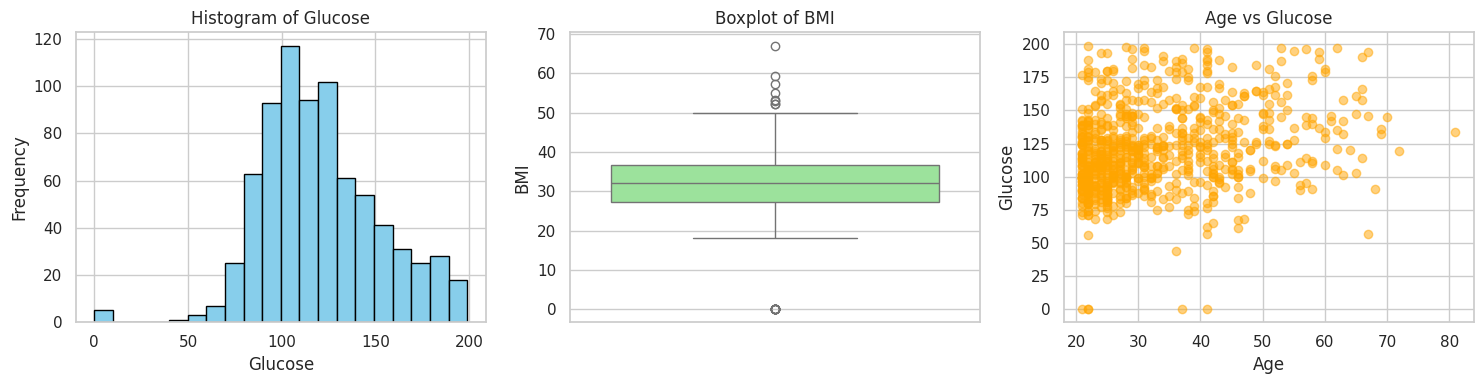

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset already loaded as df
# df = pd.read_csv('diabetes.csv')

plt.figure(figsize=(15, 4))

# (a) Histogram of Glucose
plt.subplot(1, 3, 1)
plt.hist(df['Glucose'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')

# (b) Boxplot of BMI
plt.subplot(1, 3, 2)
sns.boxplot(y=df['BMI'], color='lightgreen')
plt.title('Boxplot of BMI')

# (c) Scatter Plot: Age vs Glucose
plt.subplot(1, 3, 3)
plt.scatter(df['Age'], df['Glucose'], alpha=0.5, color='orange')
plt.title('Age vs Glucose')
plt.xlabel('Age')
plt.ylabel('Glucose')

plt.tight_layout()
plt.show()

In [9]:
# Separate diabetic and non-diabetic patients
diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

# Compare mean values
comparison = pd.DataFrame({
    'Diabetic (Outcome=1)': [diabetic['Glucose'].mean(), diabetic['BMI'].mean(), diabetic['Age'].mean()],
    'Non-Diabetic (Outcome=0)': [non_diabetic['Glucose'].mean(), non_diabetic['BMI'].mean(), non_diabetic['Age'].mean()]
}, index=['Mean Glucose', 'Mean BMI', 'Mean Age'])

print(comparison)

              Diabetic (Outcome=1)  Non-Diabetic (Outcome=0)
Mean Glucose            141.257463                  109.9800
Mean BMI                 35.142537                   30.3042
Mean Age                 37.067164                   31.1900


In [10]:
# D: Patient is diabetic (Outcome=1)
# G: Patient has glucose > 130

total = len(df)

P_D = len(df[df['Outcome']==1]) / total
P_G = len(df[df['Glucose']>130]) / total
P_D_and_G = len(df[(df['Outcome']==1) & (df['Glucose']>130)]) / total
P_D_given_G = P_D_and_G / P_G

print(f"P(D) = {P_D:.4f}")
print(f"P(G) = {P_G:.4f}")
print(f"P(D∩G) = {P_D_and_G:.4f}")
print(f"P(D|G) = {P_D_given_G:.4f}")

P(D) = 0.3490
P(G) = 0.3268
P(D∩G) = 0.2070
P(D|G) = 0.6335


In [11]:
# P(D) - Prior probability (overall probability of diabetes)
P_D = len(df[df['Outcome']==1]) / len(df)

# P(G150) - Probability of glucose > 150
P_G150 = len(df[df['Glucose']>150]) / len(df)

# P(G150|D) - Probability of glucose>150 given diabetic
P_G150_given_D = len(df[(df['Glucose']>150) & (df['Outcome']==1)]) / len(df[df['Outcome']==1])

# Bayes' Theorem: P(D|G150) = [P(G150|D) * P(D)] / P(G150)
P_D_given_G150 = (P_G150_given_D * P_D) / P_G150

print(f"Prior P(D) = {P_D:.4f}")
print(f"P(Glucose>150) = {P_G150:.4f}")
print(f"P(Glucose>150|D) = {P_G150_given_D:.4f}")
print(f"Posterior P(D|Glucose>150) = {P_D_given_G150:.4f}")

Prior P(D) = 0.3490
P(Glucose>150) = 0.1823
P(Glucose>150|D) = 0.3918
Posterior P(D|Glucose>150) = 0.7500


In [12]:
from scipy.stats import binom

n = 12       # number of patients selected
p = 0.31     # probability of being diabetic

# 1. Exactly 4 diabetic
P_exactly_4 = binom.pmf(4, n, p)

# 2. At least 4 diabetic -> P(X>=4) = 1 - P(X<=3)
P_at_least_4 = 1 - binom.cdf(3, n, p)

# 3. At most 4 diabetic -> P(X<=4)
P_at_most_4 = binom.cdf(4, n, p)

print(f"P(X=4)  = {P_exactly_4:.4f}")
print(f"P(X>=4) = {P_at_least_4:.4f}")
print(f"P(X<=4) = {P_at_most_4:.4f}")

P(X=4)  = 0.2349
P(X>=4) = 0.5381
P(X<=4) = 0.6968


In [13]:
from scipy.stats import norm

mu = 125
sigma = 30

# 1. P(X<100)
P_less_100 = norm.cdf(100, mu, sigma)

# 2. P(100<X<140)
P_between = norm.cdf(140, mu, sigma) - norm.cdf(100, mu, sigma)

# 3. P(X>150)
P_greater_150 = 1 - norm.cdf(150, mu, sigma)

print(f"P(X<100) = {P_less_100:.4f}")
print(f"P(100<X<140) = {P_between:.4f}")
print(f"P(X>150) = {P_greater_150:.4f}")

P(X<100) = 0.2023
P(100<X<140) = 0.4891
P(X>150) = 0.2023


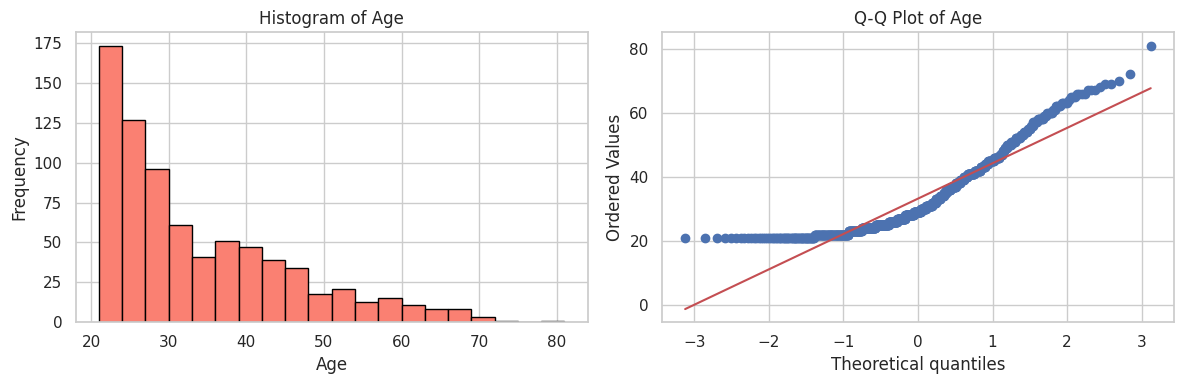

Skewness of Age = 1.1296
count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64


In [14]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df['Age'], bins=20, color='salmon', edgecolor='black')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Q-Q Plot
plt.subplot(1,2,2)
stats.probplot(df['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Age')

plt.tight_layout()
plt.show()

# Skewness and descriptive stats
print(f"Skewness of Age = {df['Age'].skew():.4f}")
print(df['Age'].describe())

In [15]:
import numpy as np

lam = 0.5  # rate parameter

# 1. PDF formula (general form)
# f(x) = lambda * e^(-lambda*x)

# 2. P(X>3)
P_X_greater_3 = np.exp(-lam * 3)

# 3. Mean waiting time
mean_wait = 1 / lam

print(f"PDF: f(x) = {lam} * e^(-{lam}x)")
print(f"P(X>3) = {P_X_greater_3:.4f}")
print(f"Mean waiting time = {mean_wait} hours")

PDF: f(x) = 0.5 * e^(-0.5x)
P(X>3) = 0.2231
Mean waiting time = 2.0 hours


In [16]:
from scipy.stats import norm
import numpy as np

mu = 120       # population mean
sigma = 15     # population std dev
n = 40         # sample size

# 1. Mean of sampling distribution
sample_mean = mu

# 2. Standard error
SE = sigma / np.sqrt(n)

# 3. P(X̄ < 125)
Z = (125 - mu) / SE
P_less_125 = norm.cdf(Z)

print(f"Mean of sampling distribution = {sample_mean}")
print(f"Standard Error (SE) = {SE:.4f}")
print(f"Z-score = {Z:.4f}")
print(f"P(X̄<125) = {P_less_125:.4f}")

Mean of sampling distribution = 120
Standard Error (SE) = 2.3717
Z-score = 2.1082
P(X̄<125) = 0.9825


In [17]:
from scipy.stats import norm
import numpy as np

n = 64
x_bar = 130
sigma = 18
confidence = 0.95

z_critical = norm.ppf(1 - (1-confidence)/2)  # Z for 95% CI
margin_error = z_critical * (sigma / np.sqrt(n))

lower = x_bar - margin_error
upper = x_bar + margin_error

print(f"Z-critical = {z_critical:.4f}")
print(f"Margin of Error = {margin_error:.4f}")
print(f"95% Confidence Interval = ({lower:.4f}, {upper:.4f})")

Z-critical = 1.9600
Margin of Error = 4.4099
95% Confidence Interval = (125.5901, 134.4099)


In [18]:
from scipy.stats import norm
import numpy as np

# Given
mu_0 = 120       # claimed population mean
x_bar = 126      # sample mean
sigma = 15       # population std dev
n = 51           # sample size
alpha = 0.05

# Test statistic
Z = (x_bar - mu_0) / (sigma / np.sqrt(n))

# Critical value for one-tailed test (right-tailed) at alpha=0.05
Z_critical = norm.ppf(1 - alpha)

# p-value
p_value = 1 - norm.cdf(Z)

print(f"Test Statistic Z = {Z:.4f}")
print(f"Critical Value (Z_critical) = {Z_critical:.4f}")
print(f"P-value = {p_value:.4f}")

if Z > Z_critical:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")

Test Statistic Z = 2.8566
Critical Value (Z_critical) = 1.6449
P-value = 0.0021
Decision: Reject H0


In [19]:
from scipy.stats import norm
import numpy as np

# Given
mu_0 = 30        # claimed population mean
x_bar = 28.5     # sample mean
sigma = 4        # population std dev
n = 65           # sample size
alpha = 0.01

# Test statistic
Z = (x_bar - mu_0) / (sigma / np.sqrt(n))

# Critical value for one-tailed test (left-tailed) at alpha=0.01
Z_critical = norm.ppf(alpha)

# p-value
p_value = norm.cdf(Z)

print(f"Test Statistic Z = {Z:.4f}")
print(f"Critical Value (Z_critical) = {Z_critical:.4f}")
print(f"P-value = {p_value:.4f}")

if Z < Z_critical:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")

Test Statistic Z = -3.0233
Critical Value (Z_critical) = -2.3263
P-value = 0.0012
Decision: Reject H0


In [20]:
# Correlation between variable pairs
corr_glucose_bmi = df['Glucose'].corr(df['BMI'])
corr_age_bp = df['Age'].corr(df['BloodPressure'])
corr_insulin_glucose = df['Insulin'].corr(df['Glucose'])

print(f"Correlation (Glucose, BMI) = {corr_glucose_bmi:.4f}")
print(f"Correlation (Age, BloodPressure) = {corr_age_bp:.4f}")
print(f"Correlation (Insulin, Glucose) = {corr_insulin_glucose:.4f}")

Correlation (Glucose, BMI) = 0.2211
Correlation (Age, BloodPressure) = 0.2395
Correlation (Insulin, Glucose) = 0.3314


In [21]:
import statsmodels.api as sm

X = df['Age']
y = df['Glucose']
X = sm.add_constant(X)  # adds intercept term

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Glucose   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     57.16
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.15e-13
Time:                        18:19:33   Log-Likelihood:                -3722.6
No. Observations:                 768   AIC:                             7449.
Df Residuals:                     766   BIC:                             7459.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.0802      3.341     29.058      0.0

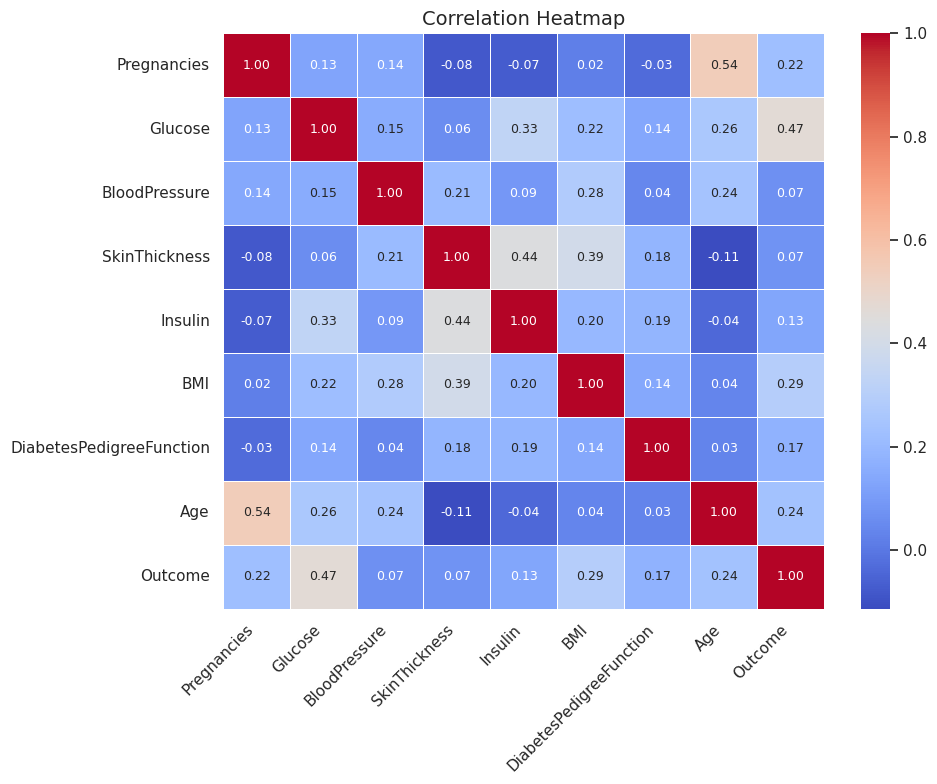

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            annot_kws={"size": 9}, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

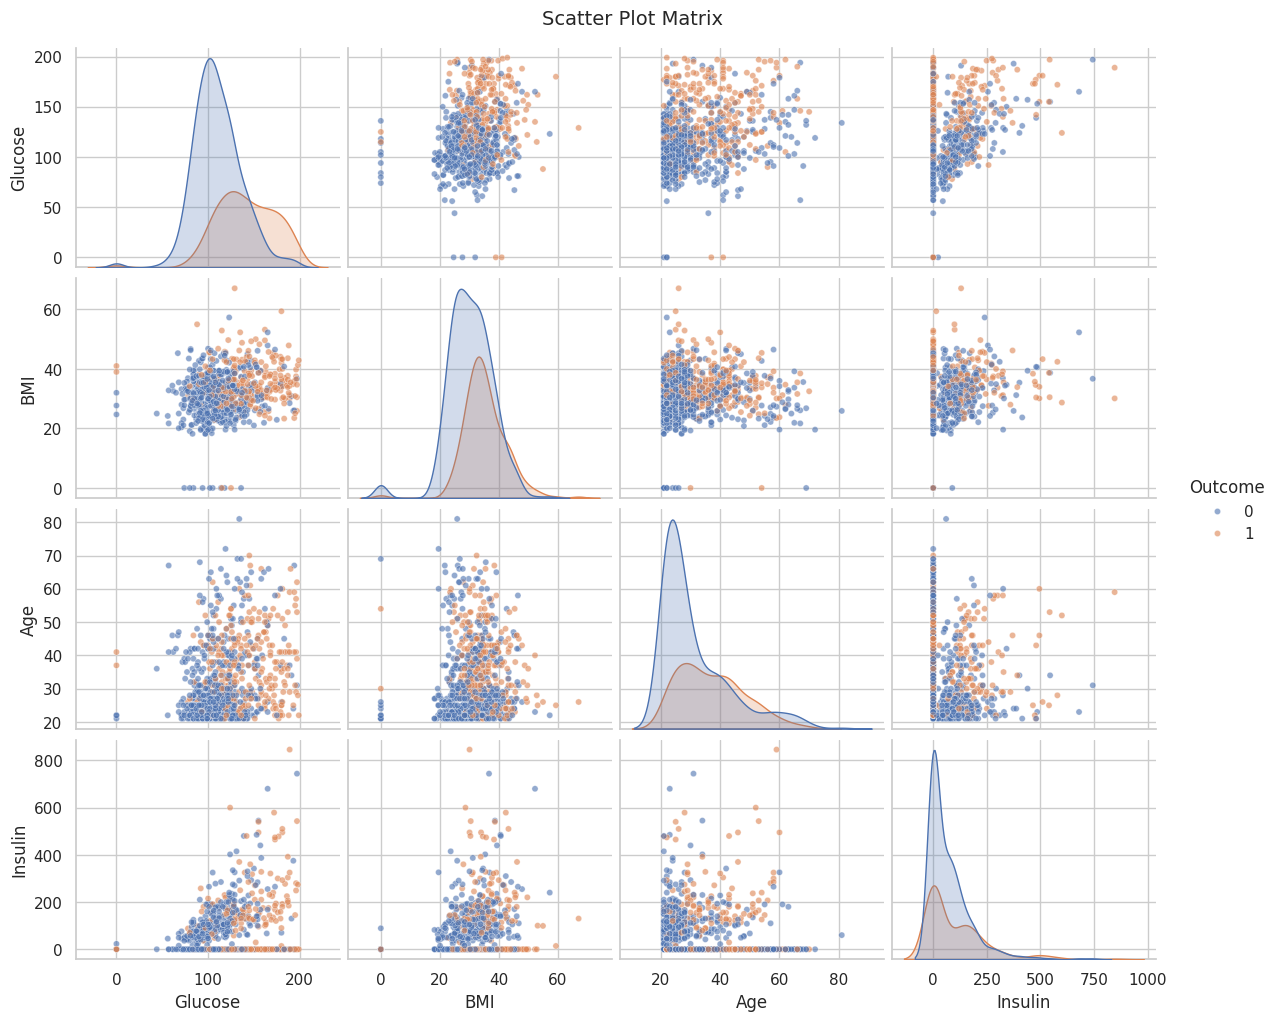

In [24]:
pair = sns.pairplot(df[['Glucose','BMI','Age','Insulin','Outcome']],
                     hue='Outcome', diag_kind='kde',
                     height=2.5, aspect=1.2,
                     plot_kws={'alpha':0.6, 's':20})
pair.fig.suptitle('Scatter Plot Matrix', y=1.02, fontsize=14)
plt.show()

In [25]:
from scipy import stats

diabetic = df[df['Outcome']==1]
non_diabetic = df[df['Outcome']==0]

for col in ['Glucose', 'BMI', 'Age']:
    t_stat, p_val = stats.ttest_ind(diabetic[col], non_diabetic[col], equal_var=False)
    print(f"{col}: t-statistic = {t_stat:.4f}, p-value = {p_val:.6f}")

Glucose: t-statistic = 13.7515, p-value = 0.000000
BMI: t-statistic = 8.6193, p-value = 0.000000
Age: t-statistic = 6.9207, p-value = 0.000000
